## Main project question
**How do different speech feature representations affect speech emotion classification performance, and how well does a CNN perform compared with simpler baseline models?**

## Recommended scope
- **Baseline model:** SVM on MFCC summary features
- **Main deep model:** CNN on mel-spectrograms
- **Optional add-on:** Random Forest on a small handcrafted/prosodic feature set

## 1. Imports and setup

This section keeps most of your original imports and adds a few utilities for:
- metadata handling
- baseline modeling
- evaluation
- spectrogram preparation for the CNN

In [ ]:
import os
import glob
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import librosa.display
import IPython.display as ipd
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('Imports loaded.')

Imports loaded.


## 2. Dataset paths

Use this section to point to the datasets you actually want to use.

You already experimented with Kaggle download code in your original notebook. Keep that if it works in your environment, but also allow manual paths so the notebook is easier to rerun.

In [ ]:
import kagglehub

# Either download from Kaggle Hub:
CREMAD_DIR = Path(kagglehub.dataset_download("ejlok1/cremad"))
# …or use a local CREMA-D folder (comment the line above):
# CREMAD_DIR = Path("/path/to/CREMA-D")

print("CREMAD_DIR =", CREMAD_DIR)

100%|██████████| 451M/451M [00:11<00:00, 40.1MB/s]

Extracting files...


CREMAD_DIR = /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1


## 3. Project plan inside the notebook

The notebook is organized into these stages:
1. build a metadata table of audio paths and labels
2. explore class balance and sample audio
3. extract two feature views
   - MFCC summary features for the baseline
   - mel-spectrograms for the CNN
4. train/evaluate the baseline model
5. train/evaluate the CNN
6. compare results and prepare presentation-ready figures

## 4. Helper functions

This section keeps the spirit of your original helper code, but updates it into a more reusable form.

In [ ]:
def speedNpitch(data):
    length_change = np.random.uniform(low=0.8, high=1.0)
    speed_fac = 1.2 / length_change
    tmp = np.interp(np.arange(0, len(data), speed_fac), np.arange(0, len(data)), data)
    minlen = min(data.shape[0], tmp.shape[0])
    out = np.zeros_like(data)
    out[:minlen] = tmp[:minlen]
    return out


def load_audio_fixed(path, sr=22050, duration=2.5, offset=0.5, augment=False):
    """Load audio, then trim/pad to a fixed length."""
    target_len = int(sr * duration)
    y, sr = librosa.load(path, sr=sr, offset=offset, duration=duration)

    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))

    if augment:
        y = speedNpitch(y)

    return y, sr


def plot_waveform_and_mel(y, sr, title='Example Audio'):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    librosa.display.waveshow(y, sr=sr, ax=axes[0])
    axes[0].set_title(f'{title} - Waveform')

    mel = librosa.feature.melspectrogram(y=y, sr=sr)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    img = librosa.display.specshow(mel_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    axes[1].set_title(f'{title} - Mel Spectrogram')
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    plt.tight_layout()


def print_confusion_matrix(cm, class_names, figsize=(8, 6), fontsize=12):
    df_cm = pd.DataFrame(cm, index=class_names, columns=class_names)
    plt.figure(figsize=figsize)
    sns.heatmap(df_cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.xticks(rotation=45, ha='right', fontsize=fontsize)
    plt.yticks(rotation=0, fontsize=fontsize)
    plt.tight_layout()


def summarize_metrics(y_true, y_pred, model_name='model'):
    return {
        'model': model_name,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro')
    }

## 5. Build a metadata table


The goal is to create one dataframe with at least these columns:
- `path`
- `label`
- `dataset`
- `speaker_id` (optional)

will probably need to customize the filename parsing based on the exact folder structure of JL Corpus and CREMA-D.

In [ ]:
def parse_cremad_label(filename):
    """Starter parser for CREMA-D style names. Edit if needed."""
    # Example idea: 1001_DFA_ANG_XX.wav -> ANG
    parts = Path(filename).stem.split('_')
    if len(parts) >= 3:
        raw = parts[2]
        mapping = {
            'ANG': 'angry',
            'DIS': 'disgust',
            'FEA': 'fear',
            'HAP': 'happy',
            'NEU': 'neutral',
            'SAD': 'sad'
        }
        return mapping.get(raw, raw.lower())
    return None


def collect_audio_metadata(audio_dir, dataset_name, parser_fn):
    rows = []
    for path in glob.glob(str(audio_dir / '**' / '*.wav'), recursive=True):
        label = parser_fn(path)
        rows.append({
            'path': path,
            'label': label,
            'dataset': dataset_name,
            'filename': Path(path).name,
        })
    return pd.DataFrame(rows)


metadata = collect_audio_metadata(CREMAD_DIR, 'CREMA-D', parse_cremad_label)
metadata = metadata.dropna(subset=['label']).reset_index(drop=True)
metadata.head()

,path,label,dataset,filename
0,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,disgust,CREMA-D,1022_IEO_DIS_HI.wav
1,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,angry,CREMA-D,1078_DFA_ANG_XX.wav
2,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,sad,CREMA-D,1073_IWL_SAD_XX.wav
3,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,fear,CREMA-D,1046_TAI_FEA_XX.wav
4,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,happy,CREMA-D,1071_IWL_HAP_XX.wav


In [ ]:
print('Total samples:', len(metadata))
print(metadata['dataset'].value_counts(dropna=False))
print(metadata['label'].value_counts(dropna=False))

Total samples: 7442
dataset
CREMA-D    7442
Name: count, dtype: int64
label
disgust    1271
angry      1271
sad        1271
fear       1271
happy      1271
neutral    1087
Name: count, dtype: int64


## 6. Basic EDA


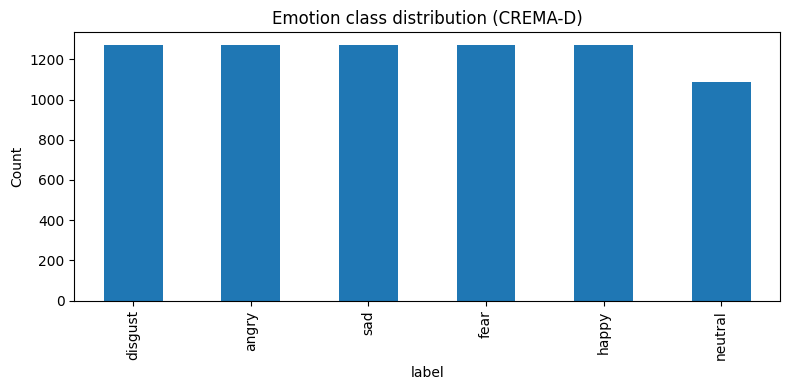

Dataset: ['CREMA-D']


In [ ]:
plt.figure(figsize=(8, 4))
metadata['label'].value_counts().plot(kind='bar')
plt.title('Emotion class distribution (CREMA-D)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print('Dataset:', metadata['dataset'].unique())

Example: /root/.cache/kagglehub/datasets/ejlok1/cremad/versions/1/AudioWAV/1022_IEO_DIS_HI.wav
Label: disgust


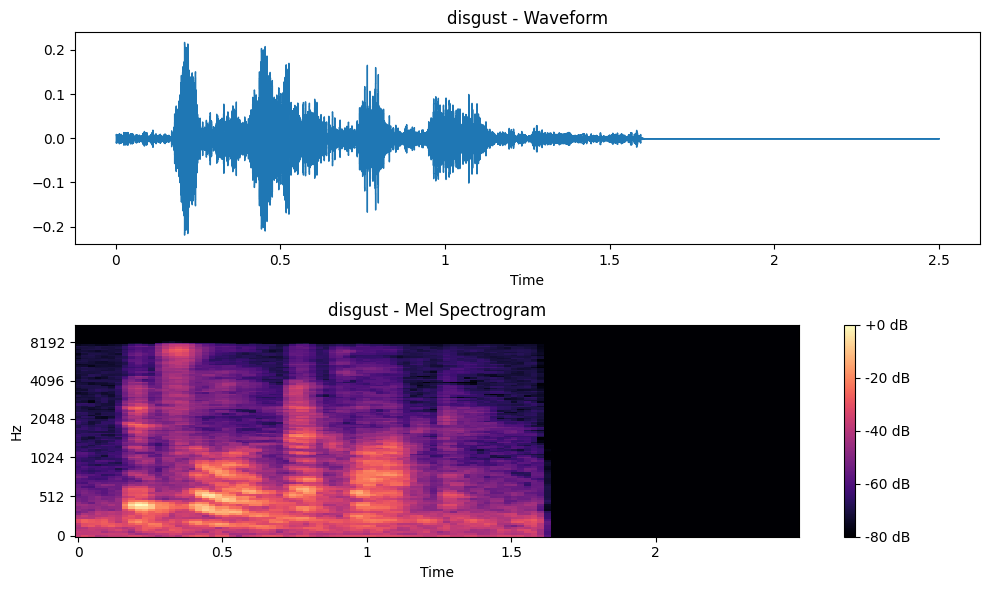

In [ ]:
# Listen to / inspect one example
example_path = metadata.iloc[0]['path']
example_label = metadata.iloc[0]['label']
y, sr = load_audio_fixed(example_path)
print('Example:', example_path)
print('Label:', example_label)
plot_waveform_and_mel(y, sr, title=example_label)
ipd.Audio(y, rate=sr)

## 7. Train / validation / test split


In [ ]:
train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    random_state=SEED,
    stratify=metadata['label']
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df['label']
)

print('train:', train_df.shape)
print('val:  ', val_df.shape)
print('test: ', test_df.shape)

train: (5209, 4)
val:   (1116, 4)
test:  (1117, 4)


## 8. Feature pipeline A: MFCC summary features for baseline models


Idea:
- compute frame-level MFCCs
- summarize over time with mean and std
- feed those vectors into SVM or Random Forest

In [ ]:
def extract_mfcc_summary(path, sr=22050, duration=2.5, n_mfcc=20):
    y, sr = load_audio_fixed(path, sr=sr, duration=duration)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    feat = np.hstack([mfcc.mean(axis=1), mfcc.std(axis=1)])
    return feat


def build_feature_matrix(df, feature_fn):
    X = []
    y = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(feature_fn(row['path']))
        y.append(row['label'])
    return np.array(X), np.array(y)

X_train_mfcc, y_train_mfcc = build_feature_matrix(train_df, extract_mfcc_summary)
X_val_mfcc, y_val_mfcc = build_feature_matrix(val_df, extract_mfcc_summary)
X_test_mfcc, y_test_mfcc = build_feature_matrix(test_df, extract_mfcc_summary)

print(X_train_mfcc.shape, y_train_mfcc.shape)

100%|██████████| 1117/1117 [00:19<00:00, 58.08it/s]

(5209, 40) (5209,)


## 9. Baseline model: SVM


In [ ]:
svm_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=3, gamma='scale'))
])

svm_clf.fit(X_train_mfcc, y_train_mfcc)
val_pred_svm = svm_clf.predict(X_val_mfcc)

print('Validation accuracy:', accuracy_score(y_val_mfcc, val_pred_svm))
print('Validation macro F1:', f1_score(y_val_mfcc, val_pred_svm, average='macro'))
print(classification_report(y_val_mfcc, val_pred_svm))

Validation accuracy: 0.5483870967741935
Validation macro F1: 0.5437427532685923
              precision    recall  f1-score   support

       angry       0.65      0.73      0.68       191
     disgust       0.55      0.46      0.50       190
        fear       0.52      0.42      0.47       191
       happy       0.48      0.49      0.49       191
     neutral       0.51      0.53      0.52       163
         sad       0.56      0.65      0.60       190

    accuracy                           0.55      1116
   macro avg       0.54      0.55      0.54      1116
weighted avg       0.55      0.55      0.54      1116



In [ ]:
# Optional second baseline if you want one more classical comparison
rf_clf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf_clf.fit(X_train_mfcc, y_train_mfcc)
val_pred_rf = rf_clf.predict(X_val_mfcc)

print('RF Validation accuracy:', accuracy_score(y_val_mfcc, val_pred_rf))
print('RF Validation macro F1:', f1_score(y_val_mfcc, val_pred_rf, average='macro'))

RF Validation accuracy: 0.4910394265232975
RF Validation macro F1: 0.47632595512117465


## 10. Feature pipeline B: mel-spectrogram tensors for the CNN


In [ ]:
def extract_mel_image(path, sr=22050, duration=2.5, n_mels=128):
    y, sr = load_audio_fixed(path, sr=sr, duration=duration)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-8)
    return mel_db[..., np.newaxis]


def build_cnn_inputs(df):
    X = []
    y = []
    for _, row in tqdm(df.iterrows(), total=len(df)):
        X.append(extract_mel_image(row['path']))
        y.append(row['label'])
    return np.array(X), np.array(y)

X_train_cnn, y_train_cnn_raw = build_cnn_inputs(train_df)
X_val_cnn, y_val_cnn_raw = build_cnn_inputs(val_df)
X_test_cnn, y_test_cnn_raw = build_cnn_inputs(test_df)

label_encoder = LabelEncoder()
y_train_cnn = to_categorical(label_encoder.fit_transform(y_train_cnn_raw))
y_val_cnn = to_categorical(label_encoder.transform(y_val_cnn_raw))
y_test_cnn = to_categorical(label_encoder.transform(y_test_cnn_raw))

print('CNN input shape:', X_train_cnn.shape)
print('Classes:', list(label_encoder.classes_))

100%|██████████| 1117/1117 [00:16<00:00, 67.16it/s]

CNN input shape: (5209, 128, 108, 1)
Classes: [np.str_('angry'), np.str_('disgust'), np.str_('fear'), np.str_('happy'), np.str_('neutral'), np.str_('sad')]


## 11. CNN model


In [ ]:
input_shape = X_train_cnn.shape[1:]
num_classes = y_train_cnn.shape[1]

cnn_model = models.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(16, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 108, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 54, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 54, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 27, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 27, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 13312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       852,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 875,718 (3.34 MB)

 Trainable params: 875,718 (3.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )
]

history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    validation_data=(X_val_cnn, y_val_cnn),
    epochs=25,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 68s 405ms/step - accuracy: 0.3575 - loss: 1.5507 - val_accuracy: 0.4561 - val_loss: 1.3784
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 404ms/step - accuracy: 0.4771 - loss: 1.3274 - val_accuracy: 0.5152 - val_loss: 1.2798
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 402ms/step - accuracy: 0.5204 - loss: 1.2189 - val_accuracy: 0.5197 - val_loss: 1.2616
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 65s 401ms/step - accuracy: 0.5686 - loss: 1.1221 - val_accuracy: 0.5421 - val_loss: 1.2432
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 403ms/step - accuracy: 0.5957 - loss: 1.0444 - val_accuracy: 0.5376 - val_loss: 1.2564
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 414ms/step - accuracy: 0.6387 - loss: 0.9544 - val_accuracy: 0.5224 - val_loss: 1.3275
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 66s 403ms/step - accuracy: 0.6639 - loss: 0.8653 - val_accuracy: 0.5108 - val_loss: 1.4133
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 413ms/step - accuracy: 0.7134 - loss: 0

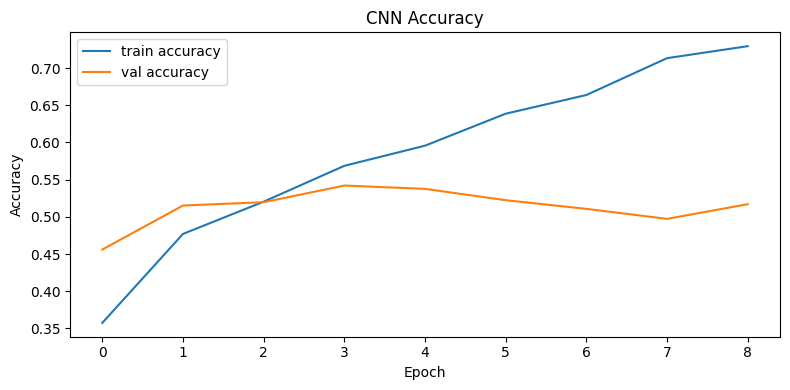

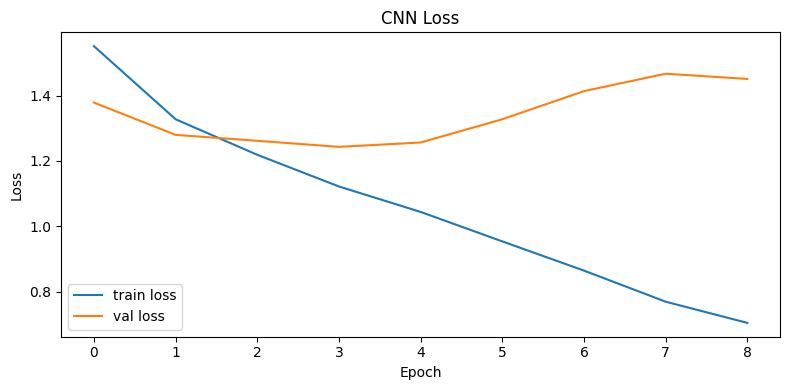

In [ ]:
def plot_history(history):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='train accuracy')
    plt.plot(history.history['val_accuracy'], label='val accuracy')
    plt.title('CNN Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='train loss')
    plt.plot(history.history['val_loss'], label='val loss')
    plt.title('CNN Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history)

## 12. Final test-set evaluation

SVM test accuracy: 0.5389435989256938
SVM test macro F1: 0.5370234469267251
              precision    recall  f1-score   support

       angry       0.72      0.64      0.68       191
     disgust       0.49      0.41      0.45       191
        fear       0.53      0.42      0.47       190
       happy       0.51      0.55      0.53       191
     neutral       0.47      0.61      0.53       163
         sad       0.53      0.62      0.57       191

    accuracy                           0.54      1117
   macro avg       0.54      0.54      0.54      1117
weighted avg       0.54      0.54      0.54      1117



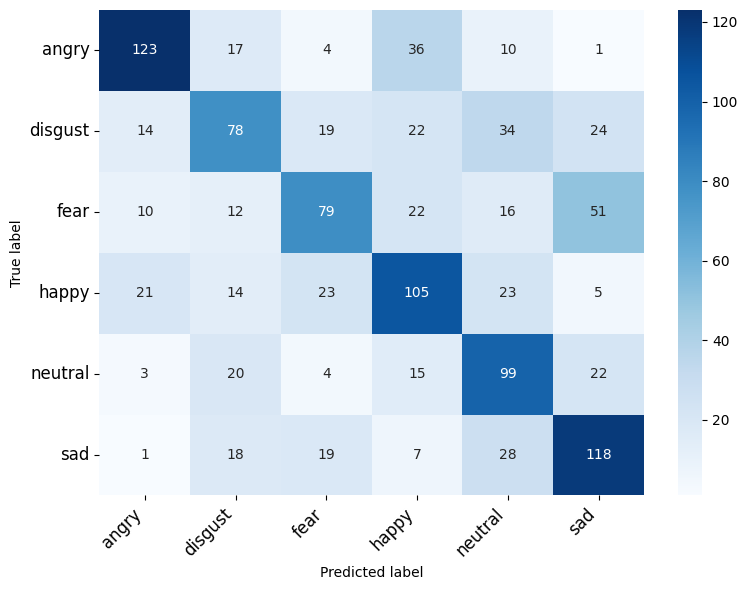

In [ ]:
# --- SVM test evaluation ---
test_pred_svm = svm_clf.predict(X_test_mfcc)
print('SVM test accuracy:', accuracy_score(y_test_mfcc, test_pred_svm))
print('SVM test macro F1:', f1_score(y_test_mfcc, test_pred_svm, average='macro'))
print(classification_report(y_test_mfcc, test_pred_svm))

cm_svm = confusion_matrix(y_test_mfcc, test_pred_svm, labels=sorted(np.unique(y_test_mfcc)))
print_confusion_matrix(cm_svm, sorted(np.unique(y_test_mfcc)))

35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step
CNN test accuracy: 0.5040286481647269
CNN test macro F1: 0.5015264887962887
              precision    recall  f1-score   support

       angry       0.68      0.66      0.67       191
     disgust       0.49      0.48      0.48       191
        fear       0.49      0.37      0.42       190
       happy       0.41      0.60      0.49       191
     neutral       0.50      0.42      0.46       163
         sad       0.49      0.49      0.49       191

    accuracy                           0.50      1117
   macro avg       0.51      0.50      0.50      1117
weighted avg       0.51      0.50      0.50      1117



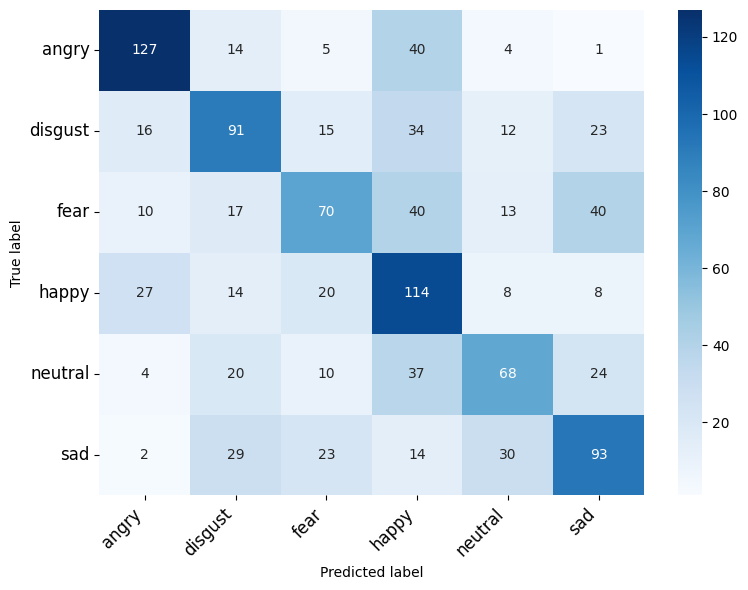

In [ ]:
# --- CNN test evaluation ---
cnn_probs = cnn_model.predict(X_test_cnn)
cnn_pred_idx = np.argmax(cnn_probs, axis=1)
cnn_true_idx = np.argmax(y_test_cnn, axis=1)
cnn_pred_labels = label_encoder.inverse_transform(cnn_pred_idx)
cnn_true_labels = label_encoder.inverse_transform(cnn_true_idx)

print('CNN test accuracy:', accuracy_score(cnn_true_labels, cnn_pred_labels))
print('CNN test macro F1:', f1_score(cnn_true_labels, cnn_pred_labels, average='macro'))
print(classification_report(cnn_true_labels, cnn_pred_labels))

cm_cnn = confusion_matrix(cnn_true_labels, cnn_pred_labels, labels=list(label_encoder.classes_))
print_confusion_matrix(cm_cnn, list(label_encoder.classes_))

## 13. Model comparison table

In [ ]:
results = []
results.append(summarize_metrics(y_test_mfcc, test_pred_svm, 'SVM + MFCC summary'))
results.append(summarize_metrics(cnn_true_labels, cnn_pred_labels, 'CNN + mel-spectrogram'))

# Optional add-on:
# test_pred_rf = rf_clf.predict(X_test_mfcc)
# results.append(summarize_metrics(y_test_mfcc, test_pred_rf, 'Random Forest + MFCC summary'))

results_df = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
results_df

,model,accuracy,macro_f1
0,SVM + MFCC summary,0.538944,0.537023
1,CNN + mel-spectrogram,0.504029,0.501526


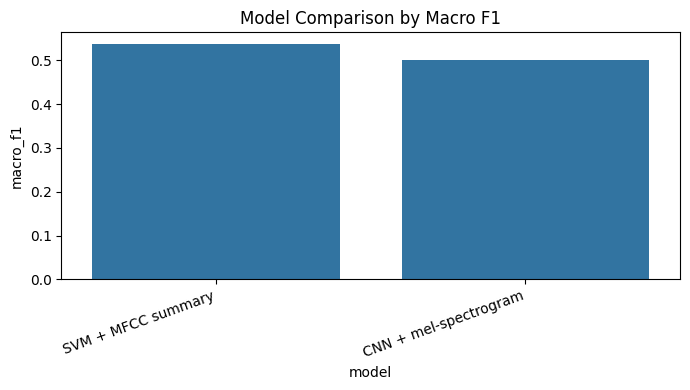

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=results_df, x='model', y='macro_f1')
plt.title('Model Comparison by Macro F1')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 14. Error analysis

In [ ]:
error_df = test_df.copy().reset_index(drop=True)
error_df['true_label'] = cnn_true_labels
error_df['pred_label'] = cnn_pred_labels
error_df['correct'] = error_df['true_label'] == error_df['pred_label']

misclassified = error_df[~error_df['correct']].copy()
misclassified.head(10)

,path,label,dataset,filename,true_label,pred_label,correct
1,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,fear,CREMA-D,1075_TIE_FEA_XX.wav,fear,neutral,False
3,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,happy,CREMA-D,1008_ITH_HAP_XX.wav,happy,fear,False
4,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,happy,CREMA-D,1021_ITH_HAP_XX.wav,happy,neutral,False
5,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,disgust,CREMA-D,1026_ITS_DIS_XX.wav,disgust,neutral,False
6,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,happy,CREMA-D,1084_DFA_HAP_XX.wav,happy,fear,False
8,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,sad,CREMA-D,1082_TIE_SAD_XX.wav,sad,disgust,False
11,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,angry,CREMA-D,1083_TIE_ANG_XX.wav,angry,disgust,False
12,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,angry,CREMA-D,1043_IEO_ANG_MD.wav,angry,happy,False
13,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,sad,CREMA-D,1077_WSI_SAD_XX.wav,sad,neutral,False
16,/root/.cache/kagglehub/datasets/ejlok1/cremad/...,disgust,CREMA-D,1059_TSI_DIS_XX.wav,disgust,angry,False


In [ ]:
# TODO: inspect a few misclassified clips manually for your presentation
# Example:
# row = misclassified.iloc[0]
# y, sr = load_audio_fixed(row['path'])
# print(row[['path', 'true_label', 'pred_label']])
# plot_waveform_and_mel(y, sr, title=f"true={row['true_label']} pred={row['pred_label']}")
# ipd.Audio(y, rate=sr)

## 15. Presentation checklist

Use the outputs of this notebook to populate your slides.

### Suggested presentation artifacts
- class distribution chart
- example waveform + mel-spectrogram
- short pipeline diagram
- baseline vs CNN comparison chart
- confusion matrices
- 2-4 misclassified examples with explanations

### Main discussion points
- which feature representation worked best?
- did CNN outperform the baseline?
- which emotions were hardest to classify?
- what likely caused the most errors?

## 16. Final TODO list for you and your partner

### Must do
- fix dataset paths
- finish the JL Corpus label parser
- verify class names are consistent across datasets
- run the SVM baseline
- run the CNN
- generate the final comparison table and confusion matrices

### Nice to do
- add Random Forest
- add a tiny handcrafted prosodic feature set
- add a small noise robustness experiment

### Skip unless you finish early
- LSTM/GRU
- raw waveform modeling
- complicated denoising pipeline
- too many extra models